In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
Num GPUs Available:  1


In [4]:
!nvidia-smi

Sun Aug 16 20:03:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
#re-size all the image to this

IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 25

In [6]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt


In [65]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/CSE443_Assignment-01_CNN/train",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/CSE443_Assignment-01_CNN/val",
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/CSE443_Assignment-01_CNN/test",
    shuffle=True,  # Set to True
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# Extract class names directly from train_ds
class_names = train_ds.class_names  # Outputs: ['NORMAL', 'PNEUMONIA']

Found 5224 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [24]:
len(train_ds)

164

In [9]:
for image_batch, label_batch in train_ds.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[0 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1]


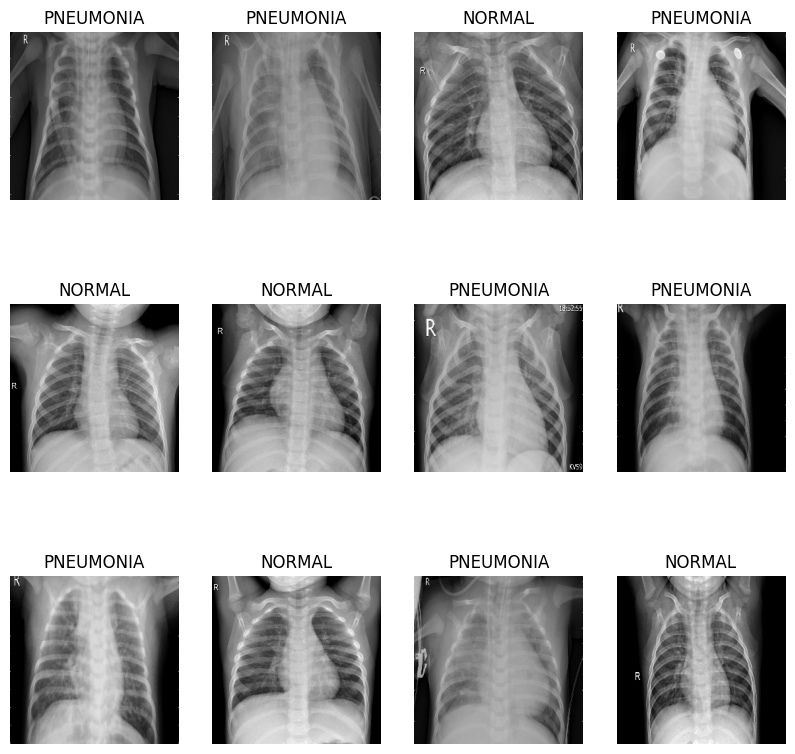

In [10]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [23]:
for image_batch, label_batch in train_ds.take(1):
   print(image_batch[0].numpy())

[[[153.53711  153.53711  153.53711 ]
  [120.85156  120.85156  120.85156 ]
  [103.71875  103.71875  103.71875 ]
  ...
  [228.30273  228.30273  228.30273 ]
  [226.15039  226.15039  226.15039 ]
  [234.3457   234.3457   234.3457  ]]

 [[137.48828  137.48828  137.48828 ]
  [104.63281  104.63281  104.63281 ]
  [109.5      109.5      109.5     ]
  ...
  [224.9375   224.9375   224.9375  ]
  [228.16992  228.16992  228.16992 ]
  [234.46875  234.46875  234.46875 ]]

 [[130.3457   130.3457   130.3457  ]
  [100.1543   100.1543   100.1543  ]
  [ 94.197266  94.197266  94.197266]
  ...
  [218.78125  218.78125  218.78125 ]
  [226.21875  226.21875  226.21875 ]
  [237.28125  237.28125  237.28125 ]]

 ...

 [[ 26.        26.        26.      ]
  [ 26.        26.        26.      ]
  [ 26.        26.        26.      ]
  ...
  [ 26.        26.        26.      ]
  [ 28.        28.        28.      ]
  [ 29.        29.        29.      ]]

 [[ 26.        26.        26.      ]
  [ 26.        26.        26.      ]


In [12]:
for image_batch, label_batch in train_ds.take(1):
    print(image_batch[0].shape)

(256, 256, 3)


In [13]:
class_names = train_ds.class_names
class_names

['NORMAL', 'PNEUMONIA']

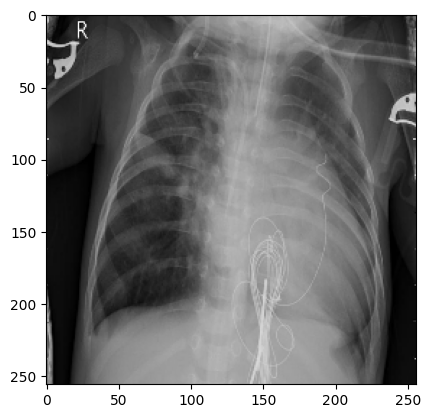

In [14]:
for image_batch, label_batch in train_ds.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))

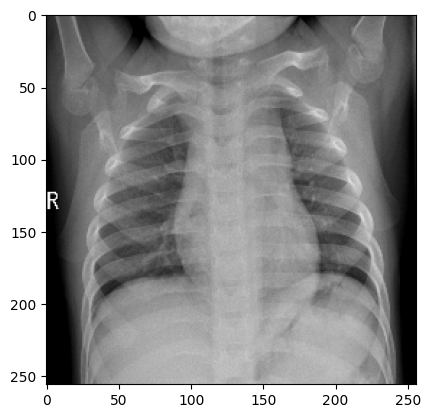

In [25]:
for image_batch, label_batch in train_ds.take(1):

  plt.imshow(image_batch[0].numpy().astype("uint8"))



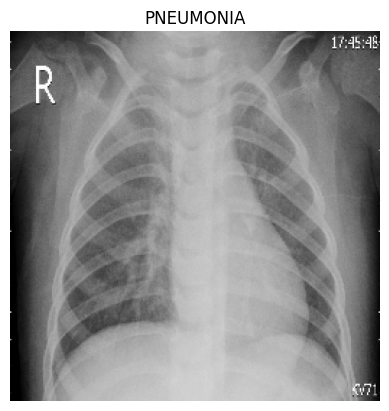

In [26]:
for image_batch, label_batch in train_ds.take(1):

  plt.imshow(image_batch[0].numpy().astype("uint8"))
  plt.title(class_names[label_batch[0]])
  plt.axis("off")


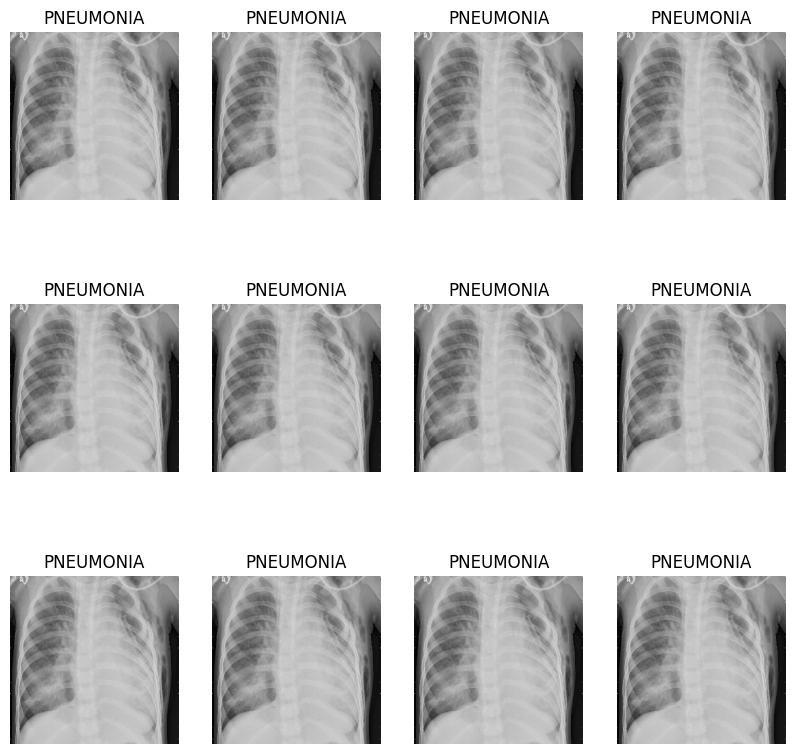

In [29]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):

    for i in range (12):
       ax = plt.subplot(3,4,i+1 )
       plt.imshow(image_batch[0].numpy().astype("uint8"))
       plt.title(class_names[label_batch[0]])
       plt.axis("off")


In [28]:
#80% ==> training
#20% ==> 10% validation, 10% test


In [27]:
len(train_ds)

164

In [19]:
len(val_ds)

1

In [ ]:
len(train_ds)

In [ ]:
len(test_ds)

In [66]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [31]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # Changed from "horizontal_and_vertical"
    layers.RandomRotation(0.1)        # Reduced from 0.2 to prevent excessive tilt
])

Creating the Model: CNN


In [33]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 2  # Updated to 2 classes ('NORMAL' and 'PNEUMONIA')

model = models.Sequential([
    # Preprocessing layers
    resize_and_rescale,
    data_augmentation,

    # 1st Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2nd Convolutional Block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd Convolutional Block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4th Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 5th Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 6th Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

# Build the model structure explicitly
model.build(input_shape=input_shape)

In [34]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 2)                │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,682 (717.51 KB)

 Trainable params: 183,682 (717.51 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [36]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.7573 - loss: 0.5316 - val_accuracy: 0.5625 - val_loss: 0.9959
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9079 - loss: 0.2373 - val_accuracy: 0.6875 - val_loss: 0.9829
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 86s 53ms/step - accuracy: 0.9305 - loss: 0.1861 - val_accuracy: 0.7500 - val_loss: 0.4064
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.9441 - loss: 0.1524 - val_accuracy: 0.5625 - val_loss: 0.8133
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.9485 - loss: 0.1466 - val_accuracy: 0.6875 - val_loss: 0.4309
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9502 - loss: 0.1357 - val_accuracy: 0.5625 - val_loss: 0.8866
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9533 - loss: 0.1295 - val_accuracy: 0.6875 - val_loss: 0.8111
Epoch 8/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 48s 53ms/step - accuracy: 0.9556 - loss: 0.1165 - 

In [37]:
scores = model.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8397 - loss: 0.5133


In [38]:
scores

[0.5132983326911926, 0.8397436141967773]

In [39]:
history.params

{'verbose': 1, 'epochs': 25, 'steps': 164}

In [40]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [41]:
 history.history['accuracy']

[0.7572740912437439,
 0.9079249501228333,
 0.9305130243301392,
 0.9441041350364685,
 0.9485068917274475,
 0.9502297043800354,
 0.9532924890518188,
 0.9555895924568176,
 0.9561638832092285,
 0.9546324610710144,
 0.9542496204376221,
 0.9575038552284241,
 0.9611408710479736,
 0.9624808430671692,
 0.961523711681366,
 0.9628636837005615,
 0.9640122652053833,
 0.9670750498771667,
 0.9632465839385986,
 0.9609494805335999,
 0.9642036557197571,
 0.964777946472168,
 0.9687978625297546,
 0.96803218126297,
 0.9709035158157349]

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

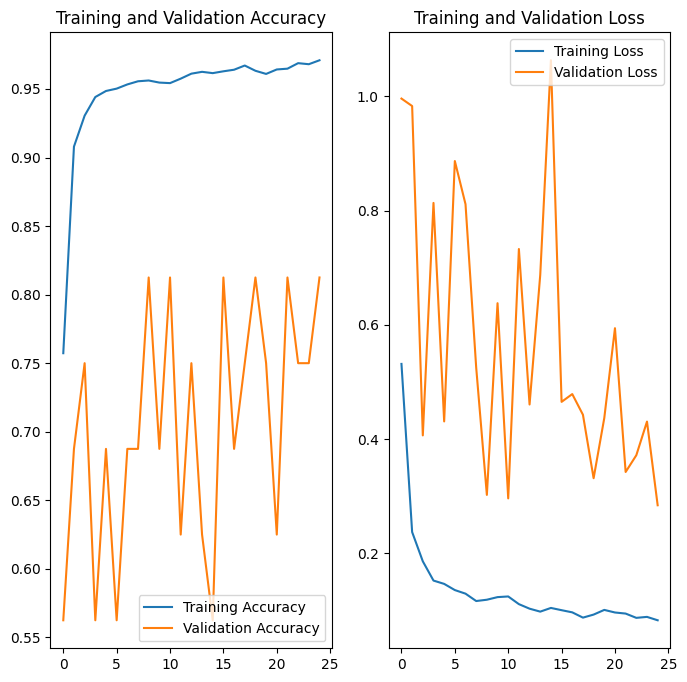

In [43]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


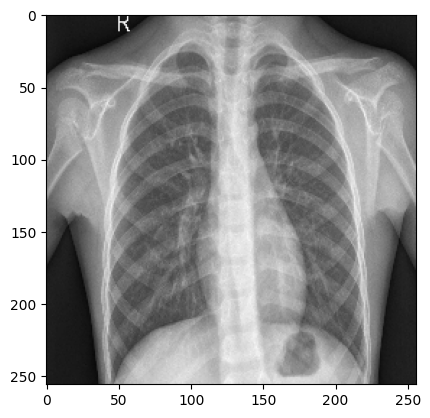

In [44]:
for images_batch, labels_batch in test_ds.take(1):

  plt.imshow(images_batch[0].numpy().astype("uint8"))

In [45]:
for images_batch, labels_batch in test_ds.take(1):

 print(images_batch[0].numpy().astype("uint8"))

[[[31 31 31]
  [30 30 30]
  [31 31 31]
  ...
  [32 32 32]
  [28 28 28]
  [34 34 34]]

 [[31 31 31]
  [33 33 33]
  [32 32 32]
  ...
  [30 30 30]
  [32 32 32]
  [32 32 32]]

 [[28 28 28]
  [32 32 32]
  [29 29 29]
  ...
  [27 27 27]
  [30 30 30]
  [31 31 31]]

 ...

 [[29 29 29]
  [30 30 30]
  [28 28 28]
  ...
  [33 33 33]
  [32 32 32]
  [31 31 31]]

 [[27 27 27]
  [28 28 28]
  [29 29 29]
  ...
  [31 31 31]
  [32 32 32]
  [33 33 33]]

 [[29 29 29]
  [28 28 28]
  [27 27 27]
  ...
  [30 30 30]
  [32 32 32]
  [33 33 33]]]


first image to predict
actual label: NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
[0.93304694 0.06695306]
predicted label: NORMAL


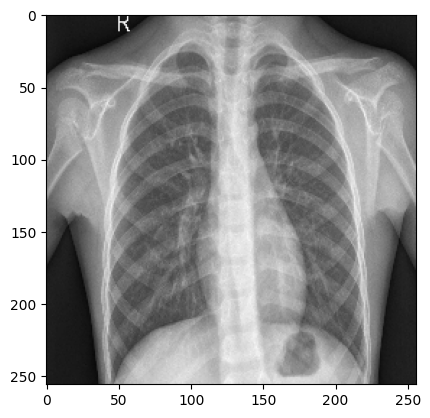

In [46]:
import numpy as np
import matplotlib.pyplot as plt

for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype("uint8")
    # Fixed the typo here (added the 's')
    first_label = labels_batch[0].numpy()

print("first image to predict")
plt.imshow(first_image)
# Added .numpy() above to make sure it reads cleanly as an index
print("actual label:", class_names[first_label])

batch_prediction = model.predict(images_batch)
print(batch_prediction[0])
print("predicted label:", class_names[np.argmax(batch_prediction[0])])

First image to predict
Actual label: NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted label: NORMAL (93.30% Confidence)


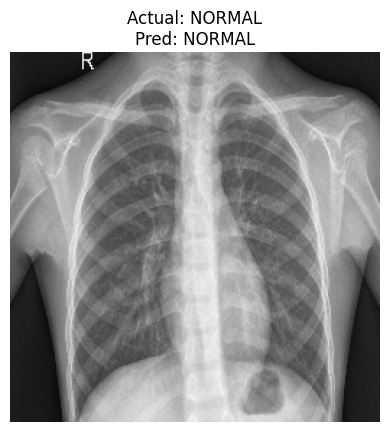

In [64]:
import numpy as np

# Take exactly 1 batch from the test set
for image_batch, label_batch in test_ds.take(1):

    # 1. Get the first image and its true label index
    first_image = image_batch[0].numpy().astype("uint8")
    first_label_index = label_batch[0].numpy()

    print("First image to predict")
    print("Actual label:", class_names[first_label_index])

    # 2. Predict on the batch and get the score for the FIRST image
    predictions = model.predict(image_batch)
    predicted_label_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    print(f"Predicted label: {class_names[predicted_label_index]} ({confidence:.2f}% Confidence)")

    # 3. Plot the image
    plt.imshow(first_image)
    plt.title(f"Actual: {class_names[first_label_index]}\nPred: {class_names[predicted_label_index]}")
    plt.axis("off")
    plt.show()
    break

In [50]:
def predict(model, img):
    # Convert image tensor/array to proper numpy format if needed
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_batch = tf.expand_dims(img_array, 0) # Create a batch (1, 256, 256, 3)

    predictions = model.predict(img_batch)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


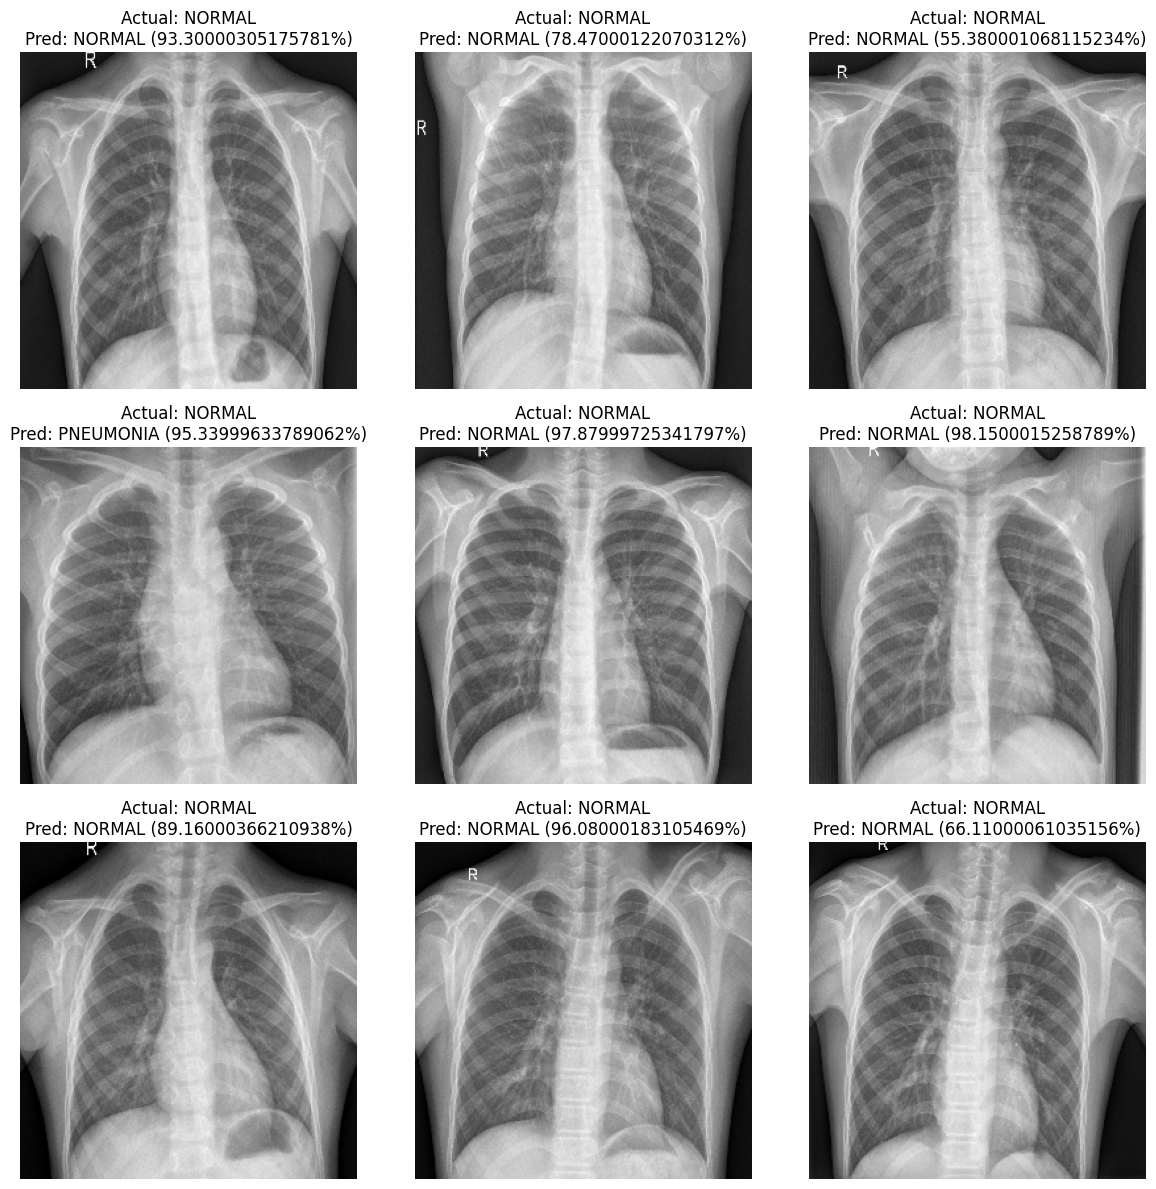

In [51]:
plt.figure(figsize=(12, 12))

for images, labels in test_ds.take(1):
    # Run prediction on the whole batch at once for speed
    predictions = model.predict(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        actual_class = class_names[labels[i]]
        predicted_class = class_names[np.argmax(predictions[i])]
        confidence = round(100 * np.max(predictions[i]), 2)

        plt.title(f"Actual: {actual_class}\nPred: {predicted_class} ({confidence}%)")
        plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


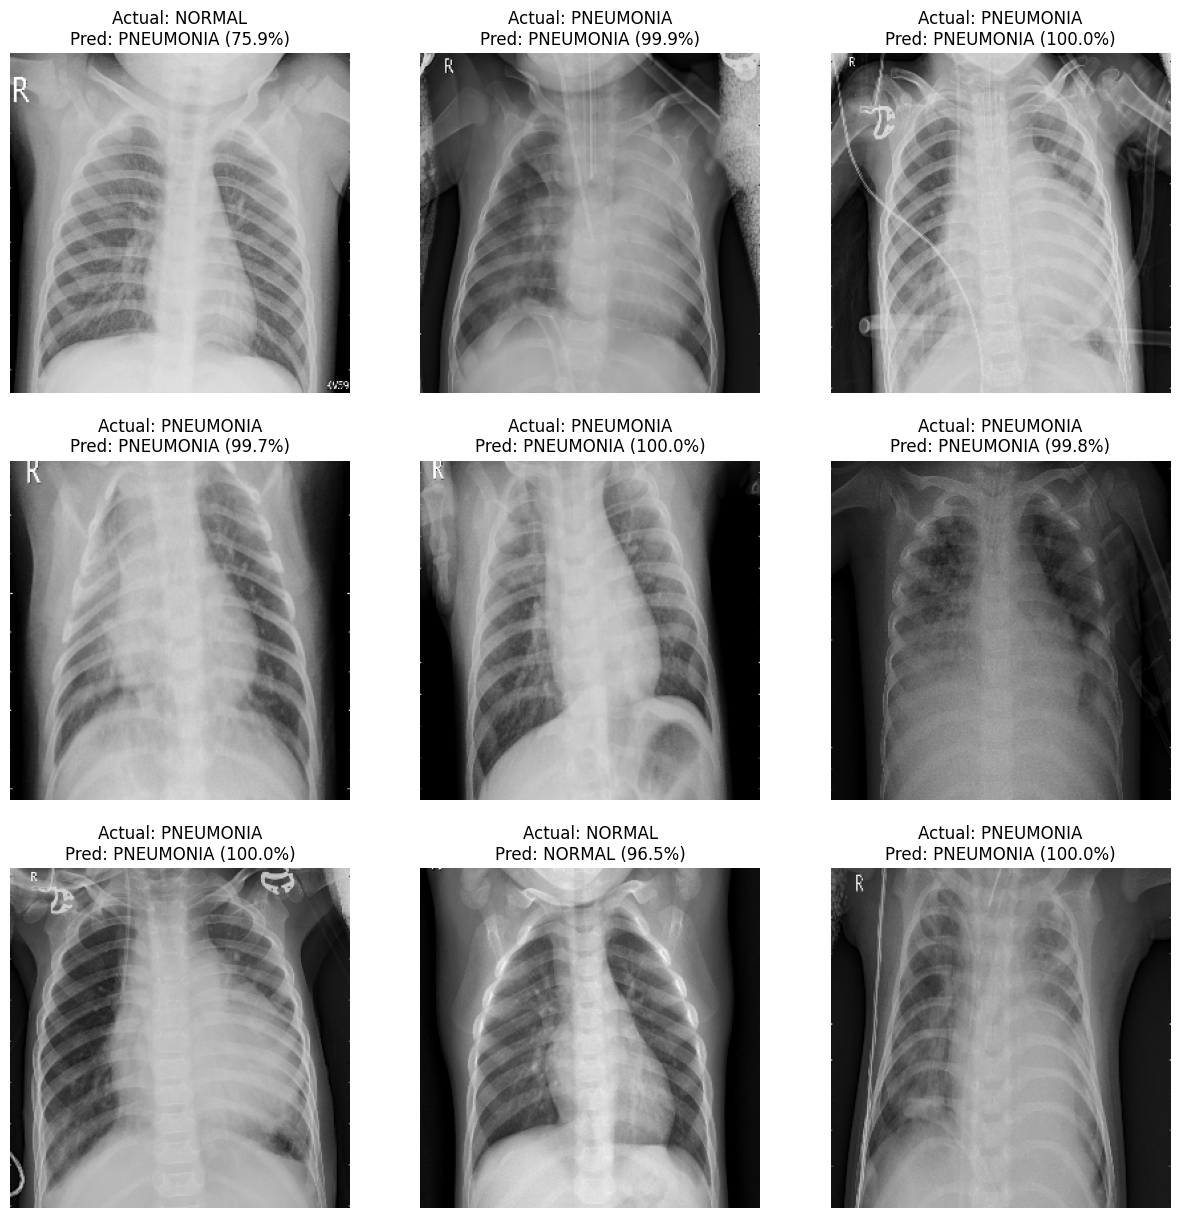

In [67]:
plt.figure(figsize=(15, 15))

for images_batch, labels_batch in test_ds.take(1):
    # Move model.predict OUTSIDE the loop so inference runs only once per batch
    batch_prediction = model.predict(images_batch)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images_batch[i].numpy().astype("uint8"))

        actual_class = class_names[labels_batch[i].numpy()]
        predicted_class = class_names[np.argmax(batch_prediction[i])]
        confidence = np.max(batch_prediction[i]) * 100

        plt.title(f"Actual: {actual_class}\nPred: {predicted_class} ({confidence:.1f}%)")
        plt.axis("off")

plt.show()